In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from datetime import datetime
from scipy import stats
import re #used to match and manipulate text patterns

In [15]:
#loading the dataset
df = pd.read_csv('/content/merged_data.csv')
df

,title,studio,domestic_gross_x,foreign_gross,year,id_x,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,Unnamed: 0,genre_ids,id_y,original_language,original_title,popularity,vote_average,vote_count
0,Inception,WB,292600000.0,535700000,2010,38,2010-07-16,Inception,"$160,000,000","$292,576,195","$835,524,642",4,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186
1,Iron Man 2,Par.,312400000.0,311500000,2010,15,2010-05-07,Iron Man 2,"$170,000,000","$312,433,331","$621,156,389",2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,6.8,12368
2,Tangled,BV,200800000.0,391000000,2010,15,2010-11-24,Tangled,"$260,000,000","$200,821,936","$586,477,240",13,"[16, 10751]",38757,en,Tangled,21.511,7.5,6407
3,Despicable Me,Uni.,251500000.0,291600000,2010,50,2010-07-09,Despicable Me,"$69,000,000","$251,513,985","$543,464,573",8,"[16, 10751, 35]",20352,en,Despicable Me,23.673,7.2,10057
4,How to Train Your Dragon,P/DW,217600000.0,277300000,2010,30,2010-03-26,How to Train Your Dragon,"$165,000,000","$217,581,232","$494,870,992",1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,7.7,7610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,Destroyer,Annapurna,1500000.0,4000000,2018,5,2018-12-25,Destroyer,"$9,000,000","$1,533,324","$3,681,096",23921,"[53, 80, 18, 28]",471507,en,Destroyer,17.815,5.9,176
1010,Gotti,VE,4300000.0,1200000,2018,64,2018-06-15,Gotti,"$10,000,000","$4,286,367","$6,089,100",24168,"[80, 18, 36, 53]",339103,en,Gotti,10.034,5.2,231
1011,Bilal: A New Breed of Hero,VE,491000.0,1700000,2018,100,2018-02-02,Bilal: A New Breed of Hero,"$30,000,000","$490,973","$648,599",25148,"[28, 12, 16]",332718,en,Bilal: A New Breed of Hero,2.707,6.8,54
1012,Lean on Pete,A24,1200000.0,1200000,2018,13,2018-04-06,Lean on Pete,"$8,000,000","$1,163,056","$2,455,027",20908,"[18, 12]",407890,en,Lean on Pete,9.307,6.9,133


In [16]:
df.columns

Index(['title', 'studio', 'domestic_gross_x', 'foreign_gross', 'year', 'id_x',
       'release_date', 'movie', 'production_budget', 'domestic_gross_y',
       'worldwide_gross', 'Unnamed: 0', 'genre_ids', 'id_y',
       'original_language', 'original_title', 'popularity', 'vote_average',
       'vote_count'],
      dtype='object')

In [25]:
 #Function to clean and convert currency strings to numeric values

def clean_currency_value(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)

    # Remove dollar signs, commas, and any other non-numeric characters except decimal point
    cleaned = re.sub(r'[^\d.]', '', str(value))
    if cleaned == '':
        return np.nan
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

# Clean and convert the currency columns
df['domestic_gross_y'] = df['domestic_gross_y'].apply(clean_currency_value)
df['production_budget'] = df['production_budget'].apply(clean_currency_value)

# Calculate revenue: domestic_gross_y - production_budget
df['revenue'] = df['domestic_gross_y'] - df['production_budget']

# Use vote_average as the rating column (ensure it's numeric)
df['rating'] = pd.to_numeric(df['vote_average'], errors='coerce')

# Check for any missing values
print("\nMissing values in key columns:")
print(f"release_date: {df['release_date'].isnull().sum()}")
print(f"domestic_gross_y: {df['domestic_gross_y'].isnull().sum()}")
print(f"production_budget: {df['production_budget'].isnull().sum()}")
print(f"vote_average: {df['rating'].isnull().sum()}")

# Remove rows with missing values in key columns
df = df.dropna(subset=['release_date', 'domestic_gross_y', 'production_budget', 'rating'])



Missing values in key columns:
release_date: 0
domestic_gross_y: 0
production_budget: 0
vote_average: 0


In [26]:
# Check for any negative revenue values and handle them
negative_revenue_count = (df['revenue'] < 0).sum()
print(f"\nNumber of movies with negative revenue: {negative_revenue_count}")

# We'll keep negative values as they represent financial losses


Number of movies with negative revenue: 462


HERE WE WILL GROUP OUR RELEASE DATE COLUMN TO REFLECT SEASONS IN OUR ANALYSIS


In [17]:
# categorising the release dates into seasons
#convert the release_date column to datetime format

# Replace 'release_date' with your actual date column name
df['release_date'] = pd.to_datetime(df['release_date'], format='%Y-%m-%d')


# Extract year, month, and day for analysis
df['year'] = df['release_date'].dt.year
df['month'] = df['release_date'].dt.month
df['day'] = df['release_date'].dt.day

In [18]:
#creating a function to categorise the data
def get_season(date):
    month = date.month
    day = date.day

    # Define seasons (you can adjust these dates if needed)
    if (month == 12 and day >= 21) or (month == 1) or (month == 2) or (month == 3 and day < 20):
        return 'Winter'
    elif (month == 3 and day >= 20) or (month == 4) or (month == 5) or (month == 6 and day < 21):
        return 'Spring'
    elif (month == 6 and day >= 21) or (month == 7) or (month == 8) or (month == 9 and day < 23):
        return 'Summer'
    else:
        return 'Autumn'

# Apply the season function
df['season'] = df['release_date'].apply(get_season)
df['season']


,season
0,Summer
1,Spring
2,Autumn
3,Summer
4,Spring
...,...
1009,Winter
1010,Spring
1011,Winter
1012,Spring


In [19]:
# Define the order of seasons for consistent analysis
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True)


CORRELATION ANALYSIS , SEASON VS RATINGS

In [29]:
#the choice to use ANOVA is because we are comparing 4 groups (seasons) on continuous metrics (ratings, revenue
# 1. Correlation Analysis: Seasons vs Ratings
print("\n=== CORRELATION ANALYSIS: SEASONS vs RATINGS ===")

# Calculate average ratings by season
rating_by_season = df.groupby('season')['rating'].mean()
print("\nAverage Ratings by Season:")
print(rating_by_season)

# Perform ANOVA test to check if differences are statistically significant
groups = [df[df['season'] == season]['rating'].values for season in season_order]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA test - F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("The differences in ratings across seasons are statistically significant.")
else:
    print("The differences in ratings across seasons are not statistically significant.")



=== CORRELATION ANALYSIS: SEASONS vs RATINGS ===

Average Ratings by Season:
season
Winter    6.211894
Spring    6.399519
Summer    6.360331
Autumn    6.641543
Name: rating, dtype: float64

ANOVA test - F-statistic: 14.937, p-value: 0.0000
The differences in ratings across seasons are statistically significant.


/tmp/ipython-input-1502898330.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_by_season = df.groupby('season')['rating'].mean()


Ratings by Season
Autumn: Highest average rating (6.64/10)

Spring: Second highest (6.40/10)

Summer: Third (6.36/10)

Winter: Lowest average rating (6.21/10)

Statistical Significance: These differences are statistically significant (p < 0.0001), meaning they represent real patterns rather than random chance.
While Autumn shows the highest average ratings, each season presents unique opportunities. The optimal strategy involves aligning your film's quality, genre, and target audience with seasonal patterns rather than simply chasing the highest-rated season.

Recommendation: Start with an Autumn release for your first high-quality production to establish critical credibility, then expand to strategic releases across other seasons based on film characteristics.



CORRELATION ANALYSIS , SEASONS VS REVENUE

In [30]:
# 2. Correlation Analysis: Seasons vs Revenue
print("\n=== CORRELATION ANALYSIS: SEASONS vs REVENUE ===")

# Calculate average revenue by season
revenue_by_season = df.groupby('season')['revenue'].mean()
print("\nAverage Revenue by Season:")
print(revenue_by_season)

# Perform ANOVA test for revenue
revenue_groups = [df[df['season'] == season]['revenue'].values for season in season_order]
f_stat_rev, p_value_rev = stats.f_oneway(*revenue_groups)
print(f"\nANOVA test - F-statistic: {f_stat_rev:.3f}, p-value: {p_value_rev:.4f}")

if p_value_rev < 0.05:
    print("The differences in revenue across seasons are statistically significant.")
else:
    print("The differences in revenue across seasons are not statistically significant.")



=== CORRELATION ANALYSIS: SEASONS vs REVENUE ===

Average Revenue by Season:
season
Winter    1.321822e+07
Spring    1.919472e+07
Summer    2.100584e+07
Autumn    1.265446e+07
Name: revenue, dtype: float64

ANOVA test - F-statistic: 1.057, p-value: 0.3666
The differences in revenue across seasons are not statistically significant.


/tmp/ipython-input-736686812.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_season = df.groupby('season')['revenue'].mean()


Revenue Performance by Season
Summer: Highest average revenue ($21.0M)

Spring: Second highest ($19.2M)

Winter: Third ($13.2M)

Autumn: Lowest average revenue ($12.7M)

Important Note: The revenue differences across seasons are not statistically significant (p = 0.37), meaning they could be due to random variation rather than meaningful seasonal patterns.


**VISUALISATION**


/tmp/ipython-input-2638125638.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_by_season = df.groupby('season')['rating'].mean().reindex(season_order)
/tmp/ipython-input-2638125638.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_season = df.groupby('season')['revenue'].mean().reindex(season_order)


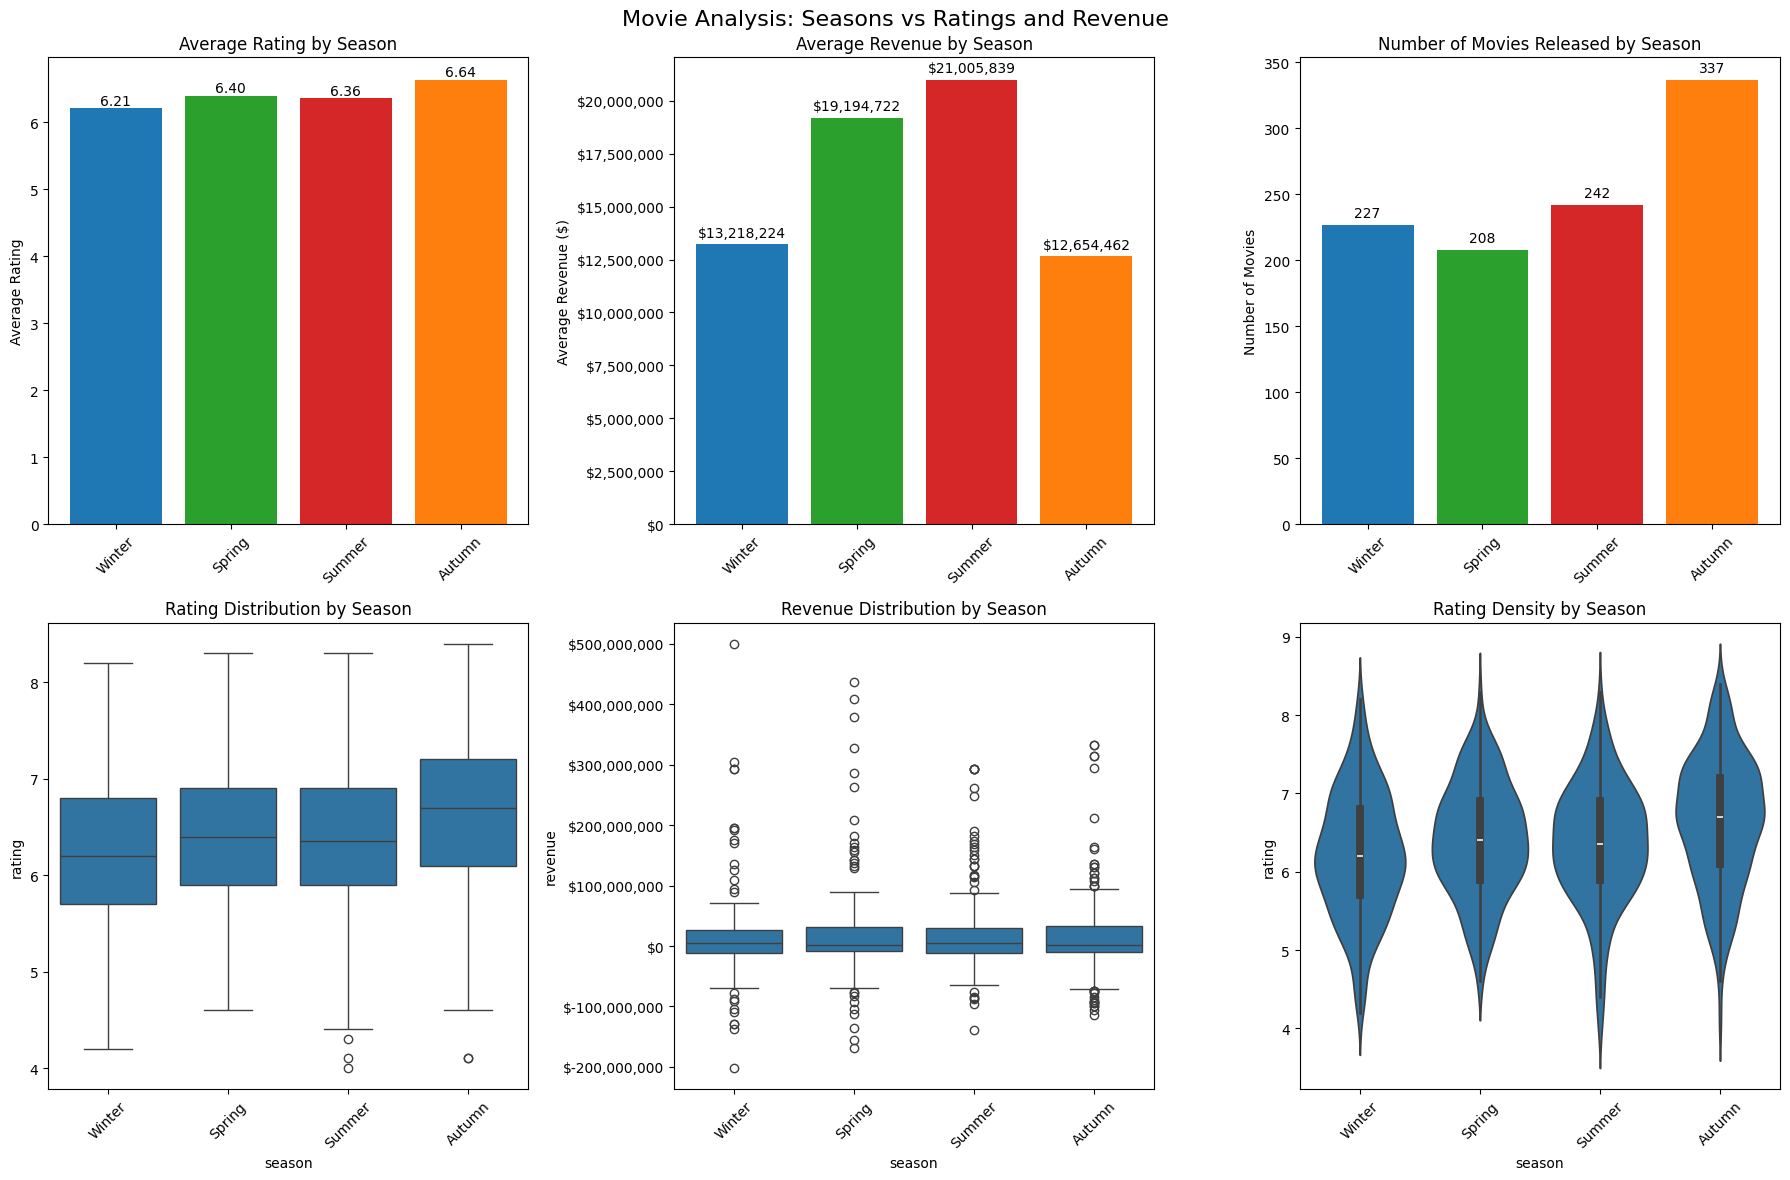

In [36]:
# CREATE THE COMPLETE FIGURE WITH ALL SUBPLOTS AT ONCE
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Movie Analysis: Seasons vs Ratings and Revenue', fontsize=16)

# 3.1 Average Rating by Season (Top Left)
rating_by_season = df.groupby('season')['rating'].mean().reindex(season_order)
bars1 = axes[0, 0].bar(rating_by_season.index, rating_by_season.values,
               color=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e'])
axes[0, 0].set_title('Average Rating by Season')
axes[0, 0].set_ylabel('Average Rating')
axes[0, 0].tick_params(axis='x', rotation=45)
# Add value labels
for bar, v in zip(bars1, rating_by_season.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom')

#  Average Revenue by Season (Top Middle)
revenue_by_season = df.groupby('season')['revenue'].mean().reindex(season_order)
bars2 = axes[0, 1].bar(revenue_by_season.index, revenue_by_season.values,
               color=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e'])
axes[0, 1].set_title('Average Revenue by Season')
axes[0, 1].set_ylabel('Average Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
# Add value labels
for bar, v in zip(bars2, revenue_by_season.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(revenue_by_season.values)*0.01,
                    f'${v:,.0f}', ha='center', va='bottom')

# 3.3 Number of Movies Released by Season (Top Right)
movies_by_season = df['season'].value_counts().reindex(season_order)
bars3 = axes[0, 2].bar(movies_by_season.index, movies_by_season.values,
               color=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e'])
axes[0, 2].set_title('Number of Movies Released by Season')
axes[0, 2].set_ylabel('Number of Movies')
axes[0, 2].tick_params(axis='x', rotation=45)
# Add value labels
for bar, v in zip(bars3, movies_by_season.values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(movies_by_season.values)*0.01,
                    f'{v}', ha='center', va='bottom')

# 3.4 Boxplot of Ratings by Season (Bottom Left)
sns.boxplot(data=df, x='season', y='rating', order=season_order, ax=axes[1, 0])
axes[1, 0].set_title('Rating Distribution by Season')
axes[1, 0].tick_params(axis='x', rotation=45)

# 3.5 Boxplot of Revenue by Season (Bottom Middle)
sns.boxplot(data=df, x='season', y='revenue', order=season_order, ax=axes[1, 1])
axes[1, 1].set_title('Revenue Distribution by Season')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 3.6 Violin Plot of Ratings by Season (Bottom Right)
sns.violinplot(data=df, x='season', y='rating', order=season_order, ax=axes[1, 2])
axes[1, 2].set_title('Rating Density by Season')
axes[1, 2].tick_params(axis='x', rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()

/tmp/ipython-input-3099670616.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_corr_data = df.groupby('season')[['rating', 'revenue']].corr().unstack().iloc[:, 1]
/tmp/ipython-input-3099670616.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_corr_matrix = df.groupby('season')[['rating', 'revenue']].corr().unstack()



=== CORRELATION BETWEEN RATING AND REVENUE BY SEASON ===
season
Winter    0.344120
Spring    0.358167
Summer    0.286878
Autumn    0.301832
Name: (rating, revenue), dtype: float64


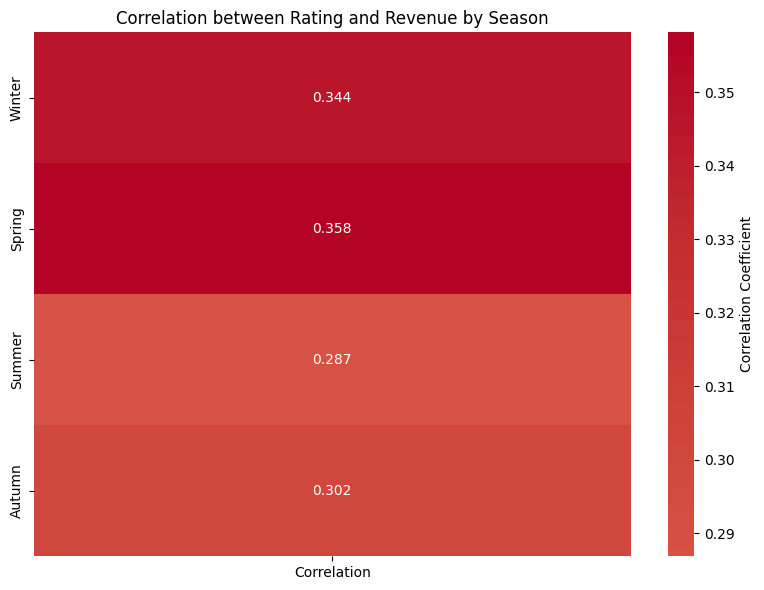

In [37]:
# . Correlation heatmap by season
season_corr_data = df.groupby('season')[['rating', 'revenue']].corr().unstack().iloc[:, 1]
print("\n=== CORRELATION BETWEEN RATING AND REVENUE BY SEASON ===")
print(season_corr_data)

# Create a heatmap of this correlation
season_corr_matrix = df.groupby('season')[['rating', 'revenue']].corr().unstack()
rating_revenue_corr = season_corr_matrix.iloc[:, 1].values.reshape(-1, 1)

plt.figure(figsize=(8, 6))
sns.heatmap(rating_revenue_corr,
            xticklabels=['Correlation'],
            yticklabels=season_order,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation between Rating and Revenue by Season')
plt.tight_layout()
plt.show()

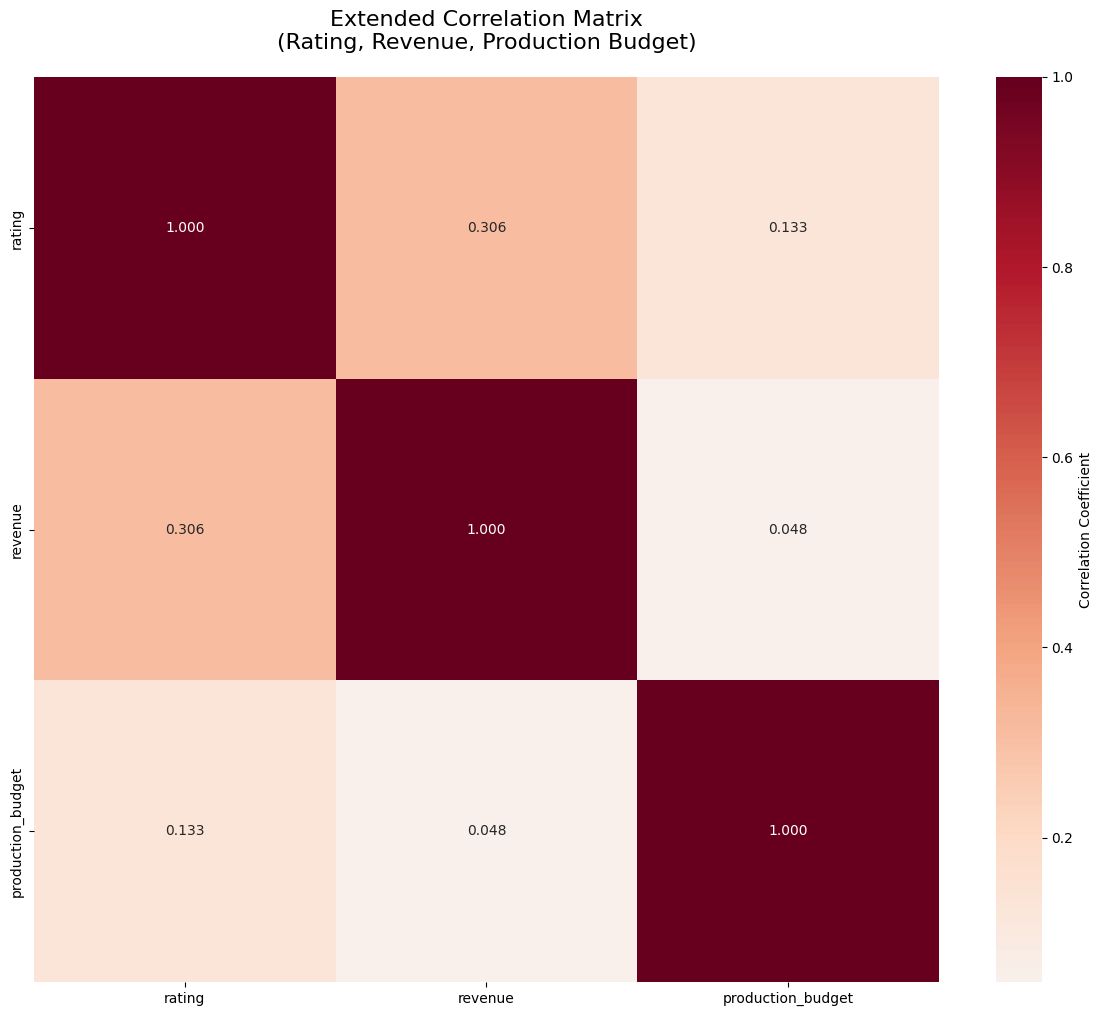

In [38]:
#  CORRELATION HEATMAP WITH ADDITIONAL VARIABLES (Optional)
plt.figure(figsize=(12, 10))

# Include additional variables if available
additional_vars = ['rating', 'revenue', 'production_budget']
if all(col in df.columns for col in additional_vars):
    extended_corr = df[additional_vars].corr()
    sns.heatmap(extended_corr,
                annot=True,
                cmap='RdBu_r',
                center=0,
                square=True,
                fmt='.3f',
                cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Extended Correlation Matrix\n(Rating, Revenue, Production Budget)',
              fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()